In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/jc-dev-comm-recruitment-task/sample_submission.csv
/kaggle/input/competitions/jc-dev-comm-recruitment-task/train.csv
/kaggle/input/competitions/jc-dev-comm-recruitment-task/test.csv


In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# 1. LOADING DATASETS
print("Loading records...")
train_df = pd.read_csv('/kaggle/input/competitions/jc-dev-comm-recruitment-task/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/jc-dev-comm-recruitment-task/test.csv')

# Saving PassengerIds for the final submission file
test_ids = test_df['PassengerId']
target_col = 'Transported'

# Joining both the datasets for pre-processing
df = pd.concat([train_df, test_df], join="inner", axis=0, ignore_index=True)

Loading records...


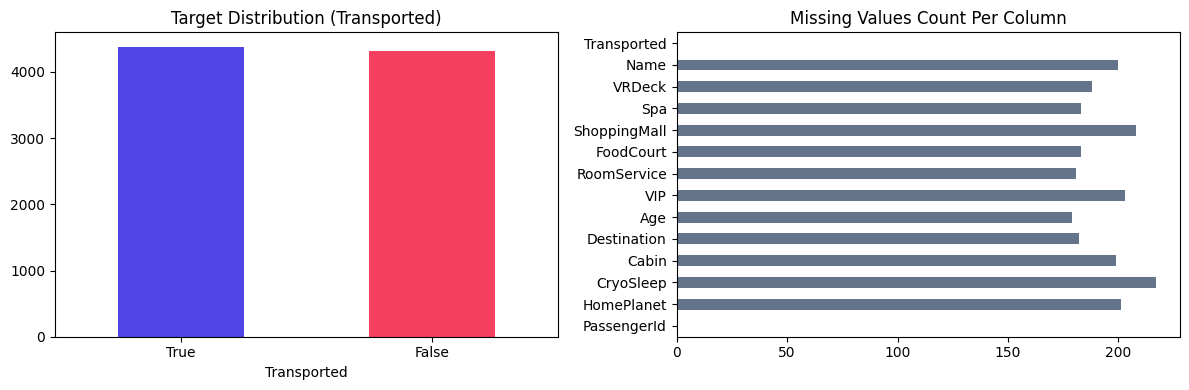

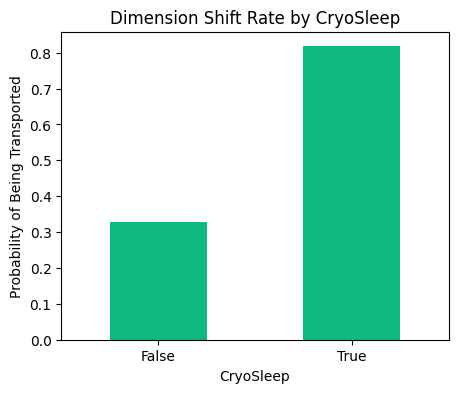

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1. Target Balance
train_df['Transported'].value_counts().plot(kind='bar', ax=ax1, color=['#4f46e5', '#f43f5e'])
ax1.set_title('Target Distribution (Transported)')
ax1.set_xticklabels(['True', 'False'], rotation=0)

# 2. Missing Values Per Column
train_df.isnull().sum().plot(kind='barh', ax=ax2, color='#64748b')
ax2.set_title('Missing Values Count Per Column')

plt.tight_layout()
plt.show()

# CryoSleep vs Transportation Rate
train_df.groupby('CryoSleep')['Transported'].mean().plot(kind='bar', color='#10b981', figsize=(5, 4))
plt.title('Dimension Shift Rate by CryoSleep')
plt.ylabel('Probability of Being Transported')
plt.xticks(rotation=0)
plt.show()

In [4]:
# 2. FEATURE ENGINEERING ENGINE
print("Deconstructing the fields...")

# A. Group Size Extraction
df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
df['Group_Size'] = df['Group'].map(df['Group'].value_counts())
df['Is_Alone'] = (df['Group_Size'] == 1).astype(int)

# B. Cabin Breakdown (Deck / Num / Side)
df['Cabin'].fillna('None/None/None', inplace=True)
df['Cabin_Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
df['Cabin_Num'] = df['Cabin'].apply(lambda x: x.split('/')[1])
df['Cabin_Side'] = df['Cabin'].apply(lambda x: x.split('/')[2])
df['Cabin_Num'] = pd.to_numeric(df['Cabin_Num'], errors='coerce')

# C. CryoSleep-Aware Luxury Spending Imputation
luxury_amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# If a passenger is in CryoSleep, their luxury spend must logically be $0
for amenity in luxury_amenities:
    df.loc[(df['CryoSleep'] == True) & (df[amenity].isna()), amenity] = 0.0
    # Imputing remaining missing values with the median of their respective home planets
    df[amenity] = df.groupby('HomePlanet')[amenity].transform(lambda x: x.fillna(x.median()))

# Calculating cumulative expenditures
df['Total_Spend'] = df[luxury_amenities].sum(axis=1)
df['No_Spending'] = (df['Total_Spend'] == 0).astype(int)

# D. Basic Demographic Imputations
df['Age'] = df.groupby(['HomePlanet', 'No_Spending'])['Age'].transform(lambda x: x.fillna(x.median()))
df['CryoSleep'] = df.groupby('No_Spending')['CryoSleep'].transform(lambda x: x.fillna(x.mode()[0])).astype(int)
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
df['VIP'] = df['VIP'].fillna(False).astype(int)

# E. Categorical Feature Encoding
categorical_cols = ['HomePlanet', 'Destination', 'Cabin_Deck', 'Cabin_Side']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# F. Dropping uninformative columns
drop_cols = ['PassengerId', 'Cabin', 'Name', 'Group']
if target_col in df.columns:
    drop_cols.append(target_col)
X_processed = df.drop(columns=drop_cols)

# Re-splitting datasets into Train and Test datasets
X_train = X_processed.iloc[:len(train_df)]
y_train = train_df[target_col].astype(int)
X_test = X_processed.iloc[len(train_df):]

print(f"Processed Dataset Shape: {X_train.shape}")

Deconstructing the fields...
Processed Dataset Shape: (8693, 17)


In [5]:
# 3. K-FOLD CROSS VALIDATION & ML MODEL
print("Initializing Stratified LightGBM Gradient Boosting Model...")

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(X_test))

# Optimal hyperparameters
lgb_params = {
    'objective': 'binary',
    'metric': 'binary_error',
    'learning_rate': 0.04,
    'num_leaves': 31,
    'max_depth': 7,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
    'random_state': 42
}

for fold, (train_idx, val_idx) in enumerate(folds.split(X_train, y_train)):
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # Creating dataset objects
    trn_data = lgb.Dataset(X_tr, label=y_tr)
    val_data = lgb.Dataset(X_val, label=y_val)
    
    # Training classifier
    clf = lgb.train(
        lgb_params, 
        trn_data, 
        num_boost_round=1000, 
        valid_sets=[trn_data, val_data], 
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    oof_predictions[val_idx] = clf.predict(X_val, num_iteration=clf.best_iteration)
    test_predictions += clf.predict(X_test, num_iteration=clf.best_iteration) / folds.n_splits

# Printing Out-Of-Fold Accuracy Score
oof_accuracy = accuracy_score(y_train, (oof_predictions > 0.5).astype(int))
print(f"Cross-Validation Dimensional Accuracy: {oof_accuracy:.4f}")

Initializing Stratified LightGBM Gradient Boosting Model...
Cross-Validation Dimensional Accuracy: 0.8120


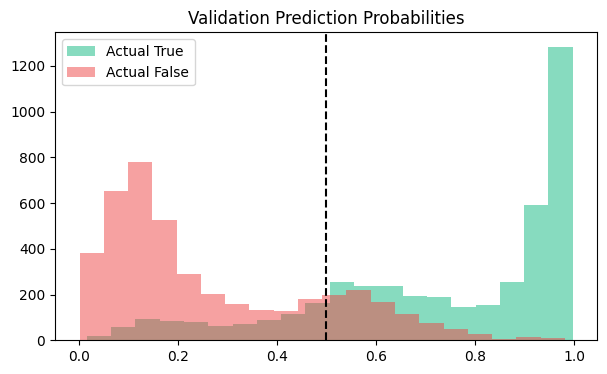

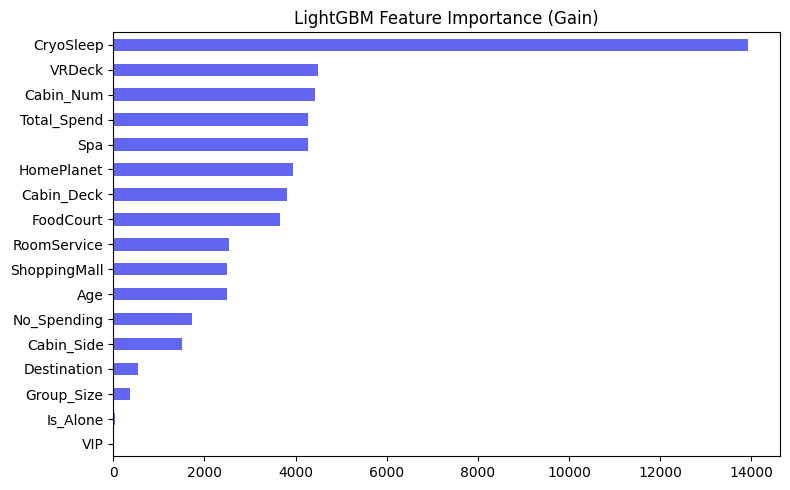

In [6]:
plt.figure(figsize=(7, 4))
# Plotting simple histograms for predicted probabilities
plt.hist(oof_predictions[y_train == 1], bins=20, alpha=0.5, label='Actual True', color='#10b981')
plt.hist(oof_predictions[y_train == 0], bins=20, alpha=0.5, label='Actual False', color='#ef4444')
plt.axvline(0.5, color='black', linestyle='--')
plt.title('Validation Prediction Probabilities')
plt.legend()
plt.show()

# Extracting and sorting features
feat_imp = pd.Series(clf.feature_importance(importance_type='gain'), index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 5), color='#6366f1')

plt.title('LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.show()

In [7]:
# 4. EXPORTING CSV FILE
print("Writing the predictions to CSV...")

submission = pd.DataFrame({'PassengerId': test_ids, 'Transported': (test_predictions > 0.5).astype(bool)})

submission.to_csv('submission.csv', index=False)
print("Analysis completed successfully. submission.csv is ready!")

Writing the predictions to CSV...
Analysis completed successfully. submission.csv is ready!
